In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import yfinance as yf
import seaborn as sns
from scipy.stats import zscore
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

import warnings
warnings.filterwarnings("ignore")


[*********************100%***********************]  2 of 2 completed


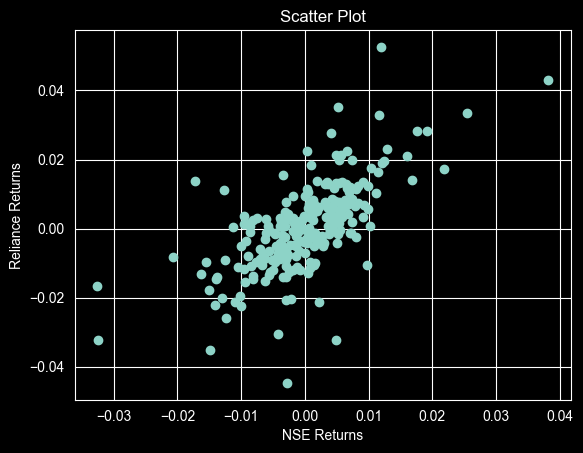

In [20]:
# Downloading Data
end = dt.date.today()
start = end - dt.timedelta(365)
a = yf.download(["RELIANCE.NS", "^NSEI"], start=start, end=end, auto_adjust=True)['Close']

# Cleaning Data
a.columns = ['reliance', 'nse']

# Returns
returns = a.pct_change().dropna()

x = returns['nse']
y = returns['reliance']

plt.scatter(x, y)
plt.xlabel("NSE Returns")
plt.ylabel("Reliance Returns")
plt.title("Scatter Plot")
plt.show()

In [21]:
# Correlation

corr = x.corr(y)
print("Correlation:", corr)

Correlation: 0.6699040673570635


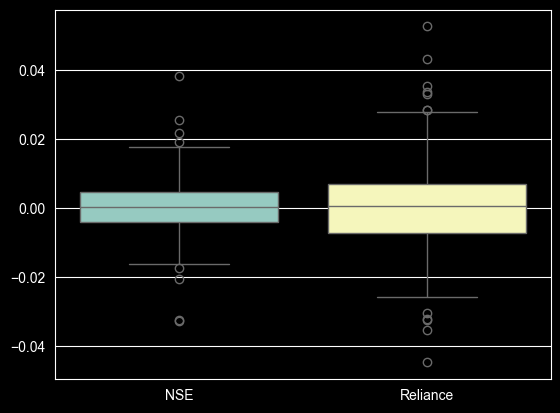

In [22]:
# Outlier Check
sns.boxplot(data=[x, y])
plt.xticks([0,1], ['NSE','Reliance'])
plt.show()

In [23]:
# outlier Check
from scipy.stats import zscore

z_x = pd.Series(zscore(x),index=x.index)
z_y = pd.Series(zscore(y),index=y.index)

outliers = (z_x.abs() > 3) | (z_y.abs() > 3)

print("Outliers:\n", returns[outliers])

Outliers:
             reliance       nse
Date                          
2025-04-07 -0.032373 -0.032433
2025-04-28  0.052599  0.012028
2025-05-12  0.043058  0.038183
2026-01-06 -0.044674 -0.002728
2026-02-03  0.033587  0.025476
2026-03-19 -0.016547 -0.032621


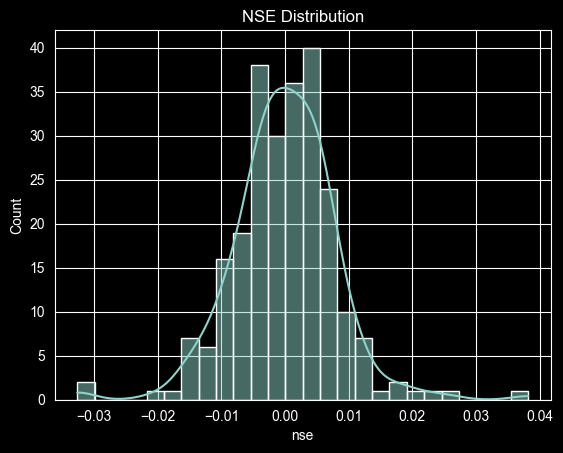

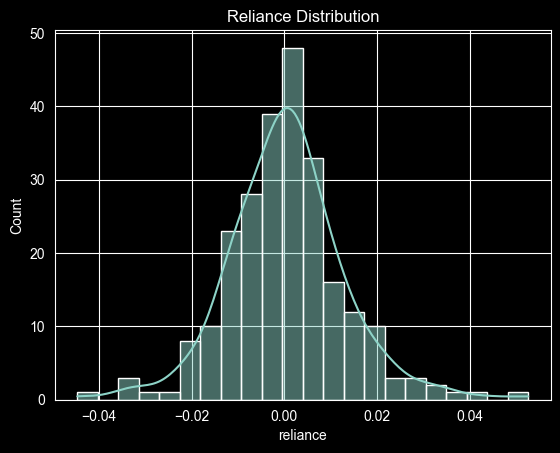

In [24]:
sns.histplot(x, kde=True)
plt.title("NSE Distribution")
plt.show()

sns.histplot(y, kde=True)
plt.title("Reliance Distribution")
plt.show()

In [25]:
# model
x = sm.add_constant(x)
model = sm.OLS(y, x).fit()
residuals = model.resid
print(residuals)

Date
2025-03-25   -0.013757
2025-03-26   -0.002038
2025-03-27   -0.001193
2025-03-28    0.000318
2025-04-01   -0.002264
                ...   
2026-03-16   -0.001844
2026-03-17   -0.006499
2026-03-18   -0.001810
2026-03-19    0.017419
2026-03-20    0.015704
Length: 244, dtype: float64


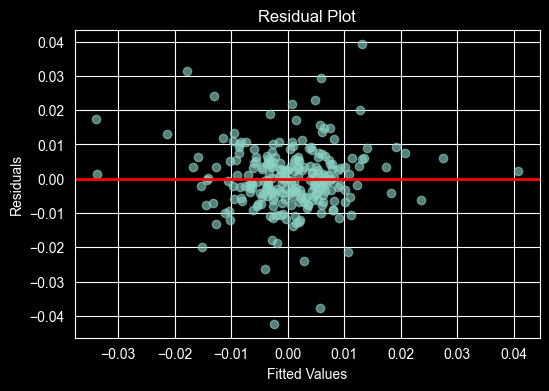

In [26]:
# Residual Plotting
plt.figure(figsize=(6,4))

plt.scatter(model.fittedvalues, residuals, alpha=0.6)  # transparency add
plt.axhline(y=0, color='red', linewidth=2)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

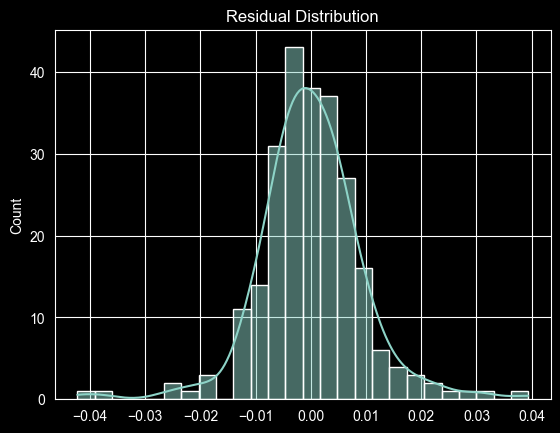

In [27]:
# Residual Distirbution

sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

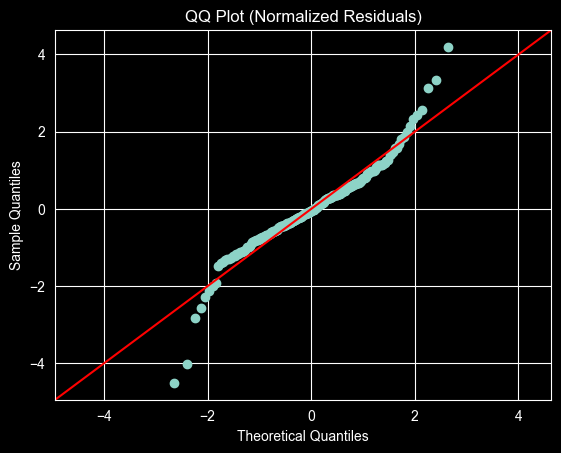

In [28]:
# Normalized  Residual qqplot
sm.qqplot(residuals,fit=True ,line='45')
plt.title("QQ Plot (Normalized Residuals)")
plt.show()

In [29]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               reliance   R-squared:                       0.449
Model:                            OLS   Adj. R-squared:                  0.446
Method:                 Least Squares   F-statistic:                     197.0
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           3.82e-33
Time:                        00:29:25   Log-Likelihood:                 792.90
No. Observations:                 244   AIC:                            -1582.
Df Residuals:                     242   BIC:                            -1575.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.001      0.844      0.3

In [30]:
print("Dependent Variable → What we are predicting (Y): Reliance Returns")
print("Independent Variable → What drives prediction (X): NSE Returns")
alpha = model.params.iloc[0]
print(f"Alpha: {alpha} → Extra return when market is 0 (stock-specific return)")
beta = model.params.iloc[1]
print(f"Beta: {beta} → Reliance moves {beta}x of NSE (market sensitivity)")
p_value = model.pvalues.iloc[1]
print(f"P-value: {p_value} → {'Significant (real relationship)' if p_value < 0.05 else 'Not significant (random)'}")
t_stat = model.tvalues.iloc[1]
print(f"T-stat: {t_stat} → Strength of signal (higher = stronger)")
std_err = model.bse.iloc[1]
print(f"Standard Error: {std_err} → Uncertainty in beta (lower = more reliable)")
r2 = model.rsquared
print(f"R²: {r2} → {r2*100:.2f}% of Reliance movement explained by NSE")
adj_r2 = model.rsquared_adj
print(f"Adjusted R²: {adj_r2} → True explanatory power (penalized version)")
f_stat = model.fvalue
print(f"F-statistic: {f_stat} → Overall model usefulness")
f_pval = model.f_pvalue
print(f"F-test p-value: {f_pval} → {'Model is valid' if f_pval < 0.05 else 'Model not useful'}")
mae = np.mean(np.abs(residuals))
print(f"MAE: {mae} → Average prediction error")
rmse = np.sqrt(np.mean(residuals**2))
print(f"RMSE: {rmse} → Typical prediction error (penalizes large errors)")
from statsmodels.stats.stattools import durbin_watson
dw = durbin_watson(residuals)
print(f"Durbin-Watson: {dw} → {'No autocorrelation' if 1.8 < dw < 2.2 else 'Autocorrelation present'}")
skew = residuals.skew()
print(f"Skewness: {skew} → {'Symmetric distribution' if abs(skew)<0.5 else 'Skewed distribution'}")
kurt = residuals.kurtosis()
print(f"Kurtosis: {kurt} → {'Fat tails (extreme moves likely)' if kurt>3 else 'Normal tails'}")
from scipy.stats import jarque_bera
jb_stat, jb_p = jarque_bera(residuals)

print(f"Jarque-Bera p-value: {jb_p} → {'Normal distribution' if jb_p>0.05 else 'Not normal'}")

Dependent Variable → What we are predicting (Y): Reliance Returns
Independent Variable → What drives prediction (X): NSE Returns
Alpha: 0.0005093325264546432 → Extra return when market is 0 (stock-specific return)
Beta: 1.056856061492542 → Reliance moves 1.056856061492542x of NSE (market sensitivity)
P-value: 3.8242531322734464e-33 → Significant (real relationship)
T-stat: 14.036358432266283 → Strength of signal (higher = stronger)
Standard Error: 0.07529417737460158 → Uncertainty in beta (lower = more reliable)
R²: 0.4487714594615372 → 44.88% of Reliance movement explained by NSE
Adjusted R²: 0.4464936555750145 → True explanatory power (penalized version)
F-statistic: 197.01935803905292 → Overall model usefulness
F-test p-value: 3.824253132273353e-33 → Model is valid
MAE: 0.006686065269317601 → Average prediction error
RMSE: 0.00938604176284519 → Typical prediction error (penalizes large errors)
Durbin-Watson: 1.9699929353194279 → No autocorrelation
Skewness: -0.05194277779460284 → Sy